In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

In [3]:
from pathlib import Path

import arviz as az
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import statsmodels.formula.api as smf
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

In [4]:
base = Path("/Users/kyledorman/data/results/estuary/train/20260305-095554/seasonal_drivers")

train_df = pd.read_parquet(base / "train_eval_pair_dataset.parquet")
timeline_df = pd.read_parquet(base / "transition_model_timeline.parquet")
events_df = pd.read_parquet(base / "transition_event_windows.parquet")

train_df.head()

,region,label_date,state,label_window_type,label_window_start_date,label_window_end_date,label_obs_gap_days,state_prev_date,state_prev,state_prev_window_type,...,is_open,transition,flow_daily_lag1,flow_window_lag1,wave_daily_lag1,wave_window_lag1,tide_daily_lag1,tide_window_lag1,month_sin,month_cos
0,14,2018-02-15,open,stable_open,2018-02-08,2018-02-19,6.0,2018-02-08,open,stable_open,...,1,persistence,0.0,0.0,0.065735,0.265737,0.703920,0.371045,0.866025,0.5
1,14,2018-02-16,open,stable_open,2018-02-08,2018-02-19,6.0,2018-02-09,open,stable_open,...,1,persistence,0.0,0.0,0.204005,0.262721,0.698762,0.509629,0.866025,0.5
2,14,2018-02-17,open,stable_open,2018-02-08,2018-02-19,6.0,2018-02-10,open,stable_open,...,1,persistence,0.0,0.0,0.299962,0.282322,0.643054,0.611073,0.866025,0.5
3,14,2018-02-18,open,stable_open,2018-02-08,2018-02-19,6.0,2018-02-11,open,stable_open,...,1,persistence,0.0,0.0,0.103136,0.256691,0.559147,0.658528,0.866025,0.5
4,14,2018-02-19,open,stable_open,2018-02-08,2018-02-19,6.0,2018-02-12,open,stable_open,...,1,persistence,0.0,0.0,0.108802,0.232567,0.390303,0.650963,0.866025,0.5


In [5]:
events_df.columns

Index(['region', 'window_start_date', 'window_end_date', 'obs_gap_days',
       'window_start_state', 'window_end_state', 'window_start_p_open',
       'window_end_p_open', 'transition', 'opening_eval_window',
       'opening_change', 'closing_eval_window', 'closing_change'],
      dtype='str')

In [6]:
events_df.transition.value_counts()

transition
open_to_open        825
closed_to_closed    732
open_to_closed      369
closed_to_open      343
Name: count, dtype: int64

In [7]:
gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf["region"] = gdf["Site code"]
gdf = gdf.set_index("region")

In [8]:
m_all_main = smf.logit(
    "is_open ~ (flow_window_lag1 + wave_window_lag1) * C(state_prev) + C(region)",
    data=train_df,
).fit()

# m_all_main = smf.logit(
#     "is_open ~ "
#     "(flow_window_lag1 + flow_daily_lag1 "
#     "+ wave_window_lag1 + wave_daily_lag1 "
#     "+ tide_window_lag1 + tide_daily_lag1) "
#     "* C(state_prev) "
#     "+ C(region)",
#     data=train_df,
# ).fit()

# m_all_main = smf.logit(
#     "is_open ~ "
#     "(flow_window_lag1 + flow_daily_lag1) "
#     "* (wave_window_lag1 + wave_daily_lag1) "
#     "* C(state_prev) "
#     "+ tide_daily_lag1 * C(state_prev) "
#     "+ flow_daily_lag1:"
#     "wave_daily_lag1:"
#     "tide_daily_lag1:"
#     "C(state_prev) "
#     "+ C(region)",
#     data=train_df,
# ).fit()

print(m_all_main.summary())

Optimization terminated successfully.
         Current function value: 0.142102
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_open   No. Observations:                25292
Model:                          Logit   Df Residuals:                    25269
Method:                           MLE   Df Model:                           22
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.7947
Time:                        10:36:54   Log-Likelihood:                -3594.1
converged:                       True   LL-Null:                       -17510.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -3.4151   

In [9]:
def prep_closed_state_df(train_df):
    df = train_df.copy()
    df = df[df["state_prev"] == "closed"].copy()

    df["flow_window"] = df["flow_window_lag1"]
    df["flow_daily"] = df["flow_daily_lag1"]
    df["wave_window"] = df["wave_window_lag1"]
    df["tide_daily"] = df["tide_daily_lag1"]

    df["flow_window_x_wave_window"] = df["flow_window"] * df["wave_window"]

    return df


def fit_closed_pymc_model(
    train_df,
    fixed_cols,
    region_slope_col=None,
    draws=1000,
    tune=2000,
    chains=4,
    target_accept=0.95,
    random_seed=42,
):
    df = prep_closed_state_df(train_df)

    required_cols = ["is_open", "region", *fixed_cols]
    if region_slope_col is not None:
        required_cols.append(region_slope_col)

    df = df.dropna(subset=required_cols).copy()

    region_cat = df["region"].astype("category")
    region_idx = region_cat.cat.codes.to_numpy()
    region_levels = region_cat.cat.categories.to_numpy()

    X_fixed = df[fixed_cols].to_numpy()
    y = df["is_open"].to_numpy()

    coords = {
        "region": region_levels,
        "fixed_effect": fixed_cols,
    }

    with pm.Model(coords=coords) as model:
        alpha = pm.Normal("alpha", 0, 2)

        beta_fixed = pm.Normal(
            "beta_fixed",
            0,
            1,
            dims="fixed_effect",
        )

        sigma_region = pm.HalfNormal("sigma_region", 1)
        region_offset = pm.Normal("region_offset", 0, 1, dims="region")
        region_intercept = pm.Deterministic(
            "region_intercept",
            sigma_region * region_offset,
            dims="region",
        )

        eta = alpha + region_intercept[region_idx] + X_fixed @ beta_fixed

        if region_slope_col is not None:
            beta_slope = pm.Normal(f"beta_{region_slope_col}", 0, 1)

            sigma_slope = pm.HalfNormal(f"sigma_{region_slope_col}", 1)
            slope_offset = pm.Normal(
                f"{region_slope_col}_offset",
                0,
                1,
                dims="region",
            )

            region_slope_dev = pm.Deterministic(
                f"region_{region_slope_col}_dev",
                sigma_slope * slope_offset,
                dims="region",
            )

            slope = beta_slope + region_slope_dev[region_idx]
            eta = eta + df[region_slope_col].to_numpy() * slope

        p = pm.Deterministic("p", pm.math.sigmoid(eta))
        y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": True},
        )

    return model, trace, region_levels


closed_model_specs = {
    "closed_full_hier_flow_daily": {
        "fixed_cols": [
            "flow_window",
            "wave_window",
            "flow_window_x_wave_window",
            "tide_daily",
            "month_sin",
            "month_cos",
        ],
        "region_slope_col": "flow_daily",
    },
    "closed_no_daily_hier_flow_window": {
        "fixed_cols": [
            "wave_window",
            "flow_window_x_wave_window",
            "month_sin",
            "month_cos",
        ],
        "region_slope_col": "flow_window",
    },
    "closed_window_fixed_no_daily": {
        "fixed_cols": [
            "flow_window",
            "wave_window",
            "flow_window_x_wave_window",
            "month_sin",
            "month_cos",
        ],
        "region_slope_col": None,
    },
    "closed_daily_flow_only": {
        "fixed_cols": [
            "wave_window",
            "tide_daily",
            "month_sin",
            "month_cos",
        ],
        "region_slope_col": "flow_daily",
    },
    "closed_window_and_daily_no_interaction": {
        "fixed_cols": [
            "flow_window",
            "wave_window",
            "tide_daily",
            "month_sin",
            "month_cos",
        ],
        "region_slope_col": "flow_daily",
    },
}

closed_models = {}
closed_traces = {}
closed_region_levels = {}

# for name, spec in closed_model_specs.items():
#     print(f"Fitting {name}")

#     model, trace, region_levels = fit_closed_pymc_model(
#         train_df=train_df,
#         fixed_cols=spec["fixed_cols"],
#         region_slope_col=spec["region_slope_col"],
#         draws=1000,
#         tune=2000,
#         chains=4,
#         target_accept=0.95,
#         random_seed=42,
#     )

#     closed_models[name] = model
#     closed_traces[name] = trace
#     closed_region_levels[name] = region_levels

In [10]:
spec = {
    "fixed_cols": [
        "wave_window",
        "month_sin",
        "month_cos",
    ],
    "region_slope_col": "flow_window",
}
name = "closed_no_daily_hier_flow_window_no_interaction"

model, trace, region_levels = fit_closed_pymc_model(
    train_df=train_df,
    fixed_cols=spec["fixed_cols"],
    region_slope_col=spec["region_slope_col"],
    draws=1000,
    tune=2000,
    chains=4,
    target_accept=0.95,
    random_seed=42,
)

closed_models[name] = model
closed_traces[name] = trace
closed_region_levels[name] = region_levels

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_fixed, sigma_region, region_offset, beta_flow_window, sigma_flow_window, flow_window_offset]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 112 seconds.


In [11]:
A = az.compare(closed_traces, ic="loo")
print(A.to_markdown())
A

|                                                 |   rank |   elpd_loo |   p_loo |   elpd_diff |   weight |      se |   dse | warning   | scale   |
|:------------------------------------------------|-------:|-----------:|--------:|------------:|---------:|--------:|------:|:----------|:--------|
| closed_no_daily_hier_flow_window_no_interaction |      0 |   -1285.61 | 32.5985 |           0 |        1 | 50.2815 |     0 | False     | log     |


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
closed_no_daily_hier_flow_window_no_interaction,0,-1285.606177,32.598548,0.0,1.0,50.281479,0.0,False,log


In [12]:
az.summary(
    closed_traces["closed_no_daily_hier_flow_window_no_interaction"],
    var_names=[
        "alpha",
        "beta_fixed",
        "beta_flow_window",
        "sigma_region",
        "sigma_flow_window",
    ],
    filter_vars="like",
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-5.728,0.435,-6.540,-4.877,0.014,0.008,1028.0,1623.0,1.00
beta_fixed[wave_window],1.044,0.246,0.581,1.493,0.004,0.004,4006.0,3254.0,1.00
beta_fixed[month_sin],0.541,0.117,0.325,0.762,0.002,0.002,4444.0,3063.0,1.00
beta_fixed[month_cos],0.446,0.096,0.255,0.619,0.002,0.001,4013.0,3009.0,1.00
beta_flow_window,4.385,0.903,2.689,6.044,0.027,0.014,1110.0,1948.0,1.01
sigma_region,1.704,0.299,1.178,2.265,0.008,0.005,1537.0,2265.0,1.00
sigma_flow_window,4.204,0.611,3.106,5.358,0.014,0.008,1877.0,2368.0,1.00


The simplified transition models use region-specific intercepts and region-specific flow-window slopes. Persistence from open also includes a flow-window by wave-window interaction, while reopening from closed does not. Daily covariates did not improve closed-state prediction and only modestly improved open-state prediction relative to the simpler hierarchical flow-window specification.

In [13]:
def prep_open_state_df(train_df):
    df = train_df.copy()
    df = df[df["state_prev"] == "open"].copy()

    df["flow_window"] = df["flow_window_lag1"]
    df["flow_daily"] = df["flow_daily_lag1"]
    df["wave_window"] = df["wave_window_lag1"]
    df["wave_daily"] = df["wave_daily_lag1"]
    df["tide_daily"] = df["tide_daily_lag1"]

    df["flow_window_x_wave_window"] = df["flow_window"] * df["wave_window"]
    df["flow_window_x_wave_daily"] = df["flow_window"] * df["wave_daily"]
    df["flow_daily_x_wave_window"] = df["flow_daily"] * df["wave_window"]
    df["flow_daily_x_wave_daily"] = df["flow_daily"] * df["wave_daily"]

    df["daily_flow_wave_tide"] = df["flow_daily"] * df["wave_daily"] * df["tide_daily"]

    return df


def fit_open_pymc_model(
    train_df,
    fixed_cols,
    region_slope_col=None,
    draws=1000,
    tune=2000,
    chains=4,
    target_accept=0.95,
    random_seed=42,
):
    df = prep_open_state_df(train_df)

    required_cols = ["is_open", "region", *fixed_cols]
    if region_slope_col is not None:
        required_cols.append(region_slope_col)

    df = df.dropna(subset=required_cols).copy()

    region_cat = df["region"].astype("category")
    region_idx = region_cat.cat.codes.to_numpy()
    region_levels = region_cat.cat.categories.to_numpy()

    X_fixed = df[fixed_cols].to_numpy()
    y = df["is_open"].to_numpy()

    coords = {
        "region": region_levels,
        "fixed_effect": fixed_cols,
    }

    with pm.Model(coords=coords) as model:
        alpha = pm.Normal("alpha", 0, 2)

        beta_fixed = pm.Normal(
            "beta_fixed",
            0,
            1,
            dims="fixed_effect",
        )

        sigma_region = pm.HalfNormal("sigma_region", 1)
        region_offset = pm.Normal("region_offset", 0, 1, dims="region")
        region_intercept = pm.Deterministic(
            "region_intercept",
            sigma_region * region_offset,
            dims="region",
        )

        eta = alpha + region_intercept[region_idx] + X_fixed @ beta_fixed

        if region_slope_col is not None:
            beta_slope = pm.Normal(f"beta_{region_slope_col}", 0, 1)

            sigma_slope = pm.HalfNormal(f"sigma_{region_slope_col}", 1)
            slope_offset = pm.Normal(
                f"{region_slope_col}_offset",
                0,
                1,
                dims="region",
            )

            region_slope_dev = pm.Deterministic(
                f"region_{region_slope_col}_dev",
                sigma_slope * slope_offset,
                dims="region",
            )

            slope = beta_slope + region_slope_dev[region_idx]

            eta = eta + df[region_slope_col].to_numpy() * slope

        p = pm.Deterministic("p", pm.math.sigmoid(eta))
        y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": True},
        )

    return model, trace, region_levels


open_model_specs = {
    # "open_full": {
    #     "fixed_cols": [
    #         "flow_window",
    #         "wave_window",
    #         "wave_daily",
    #         "flow_window_x_wave_window",
    #         # "flow_window_x_wave_daily",
    #         # "flow_daily_x_wave_window",
    #         "flow_daily_x_wave_daily",
    #         "tide_daily",
    #         "daily_flow_wave_tide",
    #         "month_sin",
    #         "month_cos",
    #     ],
    #     "region_slope_col": "flow_daily",
    # },
    "open_no_daily_hier_flow_window": {
        "fixed_cols": [
            "wave_window",
            "flow_window_x_wave_window",
            "month_sin",
            "month_cos",
        ],
        "region_slope_col": "flow_window",
    },
    # "open_hier_flow_window_tide_daily": {
    #     "fixed_cols": [
    #         "wave_window",
    #         "flow_window_x_wave_window",
    #         "tide_daily",
    #         "month_sin",
    #         "month_cos",
    #     ],
    #     "region_slope_col": "flow_window",
    # },
    # "open_hier_flow_window_daily_tide_interaction": {
    #     "fixed_cols": [
    #         "wave_window",
    #         "flow_window_x_wave_window",
    #         "tide_daily",
    #         "daily_flow_wave_tide",
    #         "month_sin",
    #         "month_cos",
    #     ],
    #     "region_slope_col": "flow_window",
    # },
    # "open_no_daily_fixed_flow_window": {
    #     "fixed_cols": [
    #         "flow_window",
    #         "wave_window",
    #         "flow_window_x_wave_window",
    #         "month_sin",
    #         "month_cos",
    #     ],
    #     "region_slope_col": None,
    # },
}

open_models = {}
open_traces = {}
open_region_levels = {}

for name, spec in open_model_specs.items():
    print(f"Fitting {name}")

    model, trace, region_levels = fit_open_pymc_model(
        train_df=train_df,
        fixed_cols=spec["fixed_cols"],
        region_slope_col=spec["region_slope_col"],
        draws=1000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=42,
    )

    open_models[name] = model
    open_traces[name] = trace
    open_region_levels[name] = region_levels

Initializing NUTS using jitter+adapt_diag...


Fitting open_no_daily_hier_flow_window


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_fixed, sigma_region, region_offset, beta_flow_window, sigma_flow_window, flow_window_offset]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 188 seconds.


In [14]:
A = az.compare(open_traces, ic="loo")

print(A.to_markdown())

A

|                                |   rank |   elpd_loo |   p_loo |   elpd_diff |   weight |      se |   dse | warning   | scale   |
|:-------------------------------|-------:|-----------:|--------:|------------:|---------:|--------:|------:|:----------|:--------|
| open_no_daily_hier_flow_window |      0 |   -1765.41 | 32.9574 |           0 |        1 | 53.5421 |     0 | False     | log     |


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
open_no_daily_hier_flow_window,0,-1765.40937,32.957414,0.0,1.0,53.542125,0.0,False,log


In [15]:
A = open_traces["open_no_daily_hier_flow_window"]

az.summary(
    A,
    var_names=[
        "alpha",
        "beta_fixed",
        "beta_flow_window",
        "sigma_region",
        "sigma_flow_window",
    ],
    filter_vars="like",
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.916,0.626,-0.315,2.082,0.022,0.013,831.0,1384.0,1.0
beta_fixed[wave_window],-2.590,0.308,-3.170,-2.008,0.005,0.004,3884.0,3375.0,1.0
beta_fixed[flow_window_x_wave_window],2.699,0.564,1.682,3.810,0.009,0.009,3931.0,3164.0,1.0
beta_fixed[month_sin],0.264,0.093,0.094,0.448,0.001,0.001,5391.0,3349.0,1.0
beta_fixed[month_cos],0.293,0.075,0.157,0.441,0.001,0.001,5532.0,2672.0,1.0
beta_flow_window,3.128,0.738,1.698,4.490,0.018,0.011,1582.0,2559.0,1.0
sigma_region,2.651,0.372,1.973,3.342,0.009,0.006,1675.0,2321.0,1.0
sigma_flow_window,3.369,0.481,2.505,4.272,0.011,0.006,1908.0,2410.0,1.0


In [16]:
# -------------------------
# Statsmodels-only prediction/evaluation utilities for m_all_main
# Uses timeline_df as the prediction timeline
# -------------------------


def add_model_features(df):
    x = df.copy()

    # These aliases are for plotting / helper consistency.
    # m_all_main itself uses the *_lag1 columns directly.
    x["flow_window"] = x["flow_window_lag1"]
    x["flow_daily"] = x["flow_daily_lag1"]
    x["wave_window"] = x["wave_window_lag1"]
    x["wave_daily"] = x["wave_daily_lag1"]
    x["tide_window"] = x["tide_window_lag1"]
    x["tide_daily"] = x["tide_daily_lag1"]

    x["flow_window_x_wave_window"] = x["flow_window"] * x["wave_window"]
    x["flow_window_x_wave_daily"] = x["flow_window"] * x["wave_daily"]
    x["flow_daily_x_wave_window"] = x["flow_daily"] * x["wave_window"]
    x["flow_daily_x_wave_daily"] = x["flow_daily"] * x["wave_daily"]

    x["daily_flow_wave_tide"] = x["flow_daily"] * x["wave_daily"] * x["tide_daily"]

    return x


def prepare_timeline_df(timeline_df, min_wave_obs=14, min_flow_obs=14):
    out = timeline_df.copy()

    out = out[(out["wave_n_obs"] > min_wave_obs) & (out["flow_n_obs"] > min_flow_obs)].copy()

    out = add_model_features(out)

    out = out.dropna(
        subset=[
            "region",
            "date",
            "p_open",
            "flow_window_lag1",
            "flow_daily_lag1",
            "wave_window_lag1",
            "wave_daily_lag1",
            "tide_window_lag1",
            "tide_daily_lag1",
            "month_sin",
            "month_cos",
        ]
    ).copy()

    out = out.sort_values(["region", "date"]).reset_index(drop=True)

    return out


def predict_statsmodels_state(model, df, state_prev):
    x = df.copy()

    x["state_prev"] = pd.Categorical(
        [state_prev] * len(x),
        categories=["closed", "open"],
    )

    return model.predict(x).to_numpy(dtype=float)


def add_statsmodels_transition_probs(model, df):
    out = df.copy()

    out["p_if_closed"] = predict_statsmodels_state(
        model,
        out,
        state_prev="closed",
    )
    out["p_if_open"] = predict_statsmodels_state(
        model,
        out,
        state_prev="open",
    )

    return out


# -------------------------
# 5. PyMC closed-only predictor
#    P(open today | previously closed)
# -------------------------


def predict_pymc_closed_model(trace_closed, df, region_levels_closed):
    x = df.copy()

    fixed_cols = [
        "wave_window",
        "month_sin",
        "month_cos",
    ]

    region_lookup = pd.Series(
        np.arange(len(region_levels_closed)),
        index=region_levels_closed,
    )

    x["region_idx"] = x["region"].map(region_lookup)

    x = x.dropna(
        subset=[
            "region_idx",
            "flow_window",
            *fixed_cols,
        ]
    ).copy()

    x["region_idx"] = x["region_idx"].astype(int)

    X_fixed = x[fixed_cols].to_numpy()
    region_idx = x["region_idx"].to_numpy()

    posterior = trace_closed.posterior

    alpha = posterior["alpha"].mean(dim=("chain", "draw")).values
    beta_fixed = posterior["beta_fixed"].mean(dim=("chain", "draw")).values

    beta_flow_window = posterior["beta_flow_window"].mean(dim=("chain", "draw")).values
    region_intercept = posterior["region_intercept"].mean(dim=("chain", "draw")).values
    region_flow_window_dev = posterior["region_flow_window_dev"].mean(dim=("chain", "draw")).values

    flow_window_slope = beta_flow_window + region_flow_window_dev[region_idx]

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + x["flow_window"].to_numpy() * flow_window_slope
    )

    out = np.full(len(df), np.nan)
    out[x.index.to_numpy()] = 1 / (1 + np.exp(-eta))

    return out


# -------------------------
# 1. Fully autoregressive simulation
# -------------------------


def simulate_full_autoregressive(
    pred_df,
    label="statsmodels_full_ar",
):
    frames = []

    for region, sub in pred_df.groupby("region", sort=False):
        sub = sub.sort_values("date").reset_index(drop=True)

        p_sim = np.empty(len(sub), dtype=float)
        p_sim[0] = float(sub["p_open"].iloc[0])

        p_if_closed = sub["p_if_closed"].to_numpy(dtype=float)
        p_if_open = sub["p_if_open"].to_numpy(dtype=float)

        for i in range(1, len(sub)):
            p_sim[i] = (1 - p_sim[i - 1]) * p_if_closed[i] + p_sim[i - 1] * p_if_open[i]

        out = sub.copy()
        out["p_open_sim"] = p_sim
        out["model"] = label

        frames.append(out)

    return pd.concat(frames, ignore_index=True)


# -------------------------
# 2. Autoregressive between confident observations
#    Reset to observed p_open at confident observed endpoints.
# -------------------------


def simulate_between_confident_lag_observations(
    pred_df,
    feature_lag_days=7,
    min_open=0.7,
    min_closed=0.3,
    label="statsmodels_conf_lag_obs_else_ar",
):
    df = pred_df.copy().sort_values(["region", "date"]).reset_index(drop=True)

    obs = df[df["is_obs"]].copy()

    obs["confident_obs_state"] = np.select(
        [
            obs["p_open"] >= min_open,
            obs["p_open"] <= min_closed,
        ],
        [
            "open",
            "closed",
        ],
        default="uncertain",
    )

    obs = obs[obs["confident_obs_state"].isin(["open", "closed"])].copy()

    lag_state = obs[["region", "date", "confident_obs_state"]].copy()
    lag_state["date"] = lag_state["date"] + pd.Timedelta(days=feature_lag_days)
    lag_state = lag_state.rename(
        columns={"confident_obs_state": f"confident_state_lag{feature_lag_days}"}
    )

    df = df.merge(
        lag_state,
        on=["region", "date"],
        how="left",
    )

    lag_col = f"confident_state_lag{feature_lag_days}"

    frames = []

    for region, sub in df.groupby("region", sort=False):
        sub = sub.sort_values("date").reset_index(drop=True)

        p_sim = np.empty(len(sub), dtype=float)
        p_sim[0] = float(sub["p_open"].iloc[0])

        p_if_closed = sub["p_if_closed"].to_numpy(dtype=float)
        p_if_open = sub["p_if_open"].to_numpy(dtype=float)
        lag_state_values = sub[lag_col].to_numpy()

        for i in range(1, len(sub)):
            if lag_state_values[i] == "closed":
                p_sim[i] = p_if_closed[i]
            elif lag_state_values[i] == "open":
                p_sim[i] = p_if_open[i]
            else:
                p_sim[i] = (1 - p_sim[i - 1]) * p_if_closed[i] + p_sim[i - 1] * p_if_open[i]

        out = sub.copy()
        out["p_open_sim"] = p_sim
        out["model"] = label

        frames.append(out)

    return pd.concat(frames, ignore_index=True)


# -------------------------
# 3. Single-step based on timeline previous state
# -------------------------


def simulate_single_step_timeline_state(
    pred_df,
    min_open=0.7,
    min_closed=0.3,
    label="statsmodels_single_step_timeline_state",
):
    out = pred_df.copy().sort_values(["region", "date"]).reset_index(drop=True)

    out["p_open_sim"] = np.nan

    closed_mask = out["prev_p_open"] < 0.5
    open_mask = out["prev_p_open"] >= 0.5

    out.loc[closed_mask, "p_open_sim"] = out.loc[closed_mask, "p_if_closed"]
    out.loc[open_mask, "p_open_sim"] = out.loc[open_mask, "p_if_open"]

    out["model"] = label

    return out


def simulate_single_state_timeline_state(
    pred_df,
    state: str,
    label="statsmodels_single_step_timeline_state",
):
    out = pred_df.copy().sort_values(["region", "date"]).reset_index(drop=True)

    out["p_open_sim"] = np.nan

    closed_mask = out["prev_p_open"] < 0.5
    open_mask = out["prev_p_open"] >= 0.5

    if state == "closed":
        out["p_open_sim"] = out["p_if_closed"]
    else:
        out["p_open_sim"] = out["p_if_open"]

    out["model"] = label

    return out


def simulate_pymc_all_closed(
    pred_df,
    trace_closed,
    region_levels_closed,
    label="pymc_all_closed",
):
    out = pred_df.copy().sort_values(["region", "date"]).reset_index(drop=True)

    out["p_open_sim"] = predict_pymc_closed_model(
        trace_closed=trace_closed,
        df=out,
        region_levels_closed=region_levels_closed,
    )

    out["model"] = label

    return out


def predict_pymc_open_model(trace_open, df, region_levels_open):
    x = df.copy()

    fixed_cols = [
        "wave_window",
        "flow_window_x_wave_window",
        "month_sin",
        "month_cos",
    ]

    region_lookup = pd.Series(
        np.arange(len(region_levels_open)),
        index=region_levels_open,
    )

    x["region_idx"] = x["region"].map(region_lookup)

    x = x.dropna(
        subset=[
            "region_idx",
            "flow_window",
            *fixed_cols,
        ]
    ).copy()

    x["region_idx"] = x["region_idx"].astype(int)

    X_fixed = x[fixed_cols].to_numpy()
    region_idx = x["region_idx"].to_numpy()

    posterior = trace_open.posterior

    alpha = posterior["alpha"].mean(dim=("chain", "draw")).values
    beta_fixed = posterior["beta_fixed"].mean(dim=("chain", "draw")).values

    beta_flow_window = posterior["beta_flow_window"].mean(dim=("chain", "draw")).values
    region_intercept = posterior["region_intercept"].mean(dim=("chain", "draw")).values
    region_flow_window_dev = posterior["region_flow_window_dev"].mean(dim=("chain", "draw")).values

    flow_window_slope = beta_flow_window + region_flow_window_dev[region_idx]

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + x["flow_window"].to_numpy() * flow_window_slope
    )

    out = np.full(len(df), np.nan)
    out[x.index.to_numpy()] = 1 / (1 + np.exp(-eta))

    return out


def simulate_pymc_all_open(
    pred_df,
    trace_open,
    region_levels_open,
    label="pymc_all_open",
):
    out = pred_df.copy().sort_values(["region", "date"]).reset_index(drop=True)

    out["p_open_sim"] = predict_pymc_open_model(
        trace_open=trace_open,
        df=out,
        region_levels_open=region_levels_open,
    )

    out["model"] = label

    return out


# -------------------------
# 4. Run all three versions for m_all_main
# -------------------------

record_df = prepare_timeline_df(timeline_df)

record_df = add_statsmodels_transition_probs(
    model=m_all_main,
    df=record_df,
)

sim_full_ar = simulate_full_autoregressive(
    record_df,
    label="auto_regressive",
)

sim_between_obs = simulate_between_confident_lag_observations(
    record_df,
    feature_lag_days=7,
    min_open=0.7,
    min_closed=0.3,
    label="gap_fill",
)

sim_single_step = simulate_single_step_timeline_state(
    record_df,
    min_open=0.7,
    min_closed=0.3,
    label="single_step",
)

sim_all_closed = simulate_single_state_timeline_state(
    record_df,
    state="closed",
    label="all_closed",
)
sim_all_open = simulate_single_state_timeline_state(
    record_df,
    state="open",
    label="all_open",
)
sim_pymc_all_closed = simulate_pymc_all_closed(
    pred_df=record_df,
    trace_closed=closed_traces["closed_no_daily_hier_flow_window_no_interaction"],
    region_levels_closed=closed_region_levels["closed_no_daily_hier_flow_window_no_interaction"],
    label="pymc_all_closed",
)
sim_pymc_all_open = simulate_pymc_all_open(
    pred_df=record_df,
    trace_open=open_traces["open_no_daily_hier_flow_window"],
    region_levels_open=open_region_levels["open_no_daily_hier_flow_window"],
    label="pymc_all_open",
)


sim_all = pd.concat(
    [
        sim_full_ar,
        sim_between_obs,
        sim_single_step,
        sim_all_closed,
        sim_all_open,
        sim_pymc_all_closed,
        sim_pymc_all_open,
    ],
    ignore_index=True,
)

sim_all["model"].unique().tolist()

['auto_regressive',
 'gap_fill',
 'single_step',
 'all_closed',
 'all_open',
 'pymc_all_closed',
 'pymc_all_open']

In [17]:
MODEL_COLORS = {
    "auto_regressive": "tab:red",
    "gap_fill": "tab:green",
    "single_step": "tab:purple",
    "all_open": "tab:pink",
    "all_closed": "tab:orange",
    "pymc_all_closed": "tab:green",
}

OBS_COLOR = "black"
OPEN_COLOR = "tab:blue"
CLOSED_COLOR = "tab:orange"
UNCERTAIN_COLOR = "tab:gray"


def plot_broken_line(
    ax,
    df,
    x_col,
    y_col,
    max_gap_days=3,
    label=None,
    **plot_kwargs,
):
    d = df.dropna(subset=[x_col, y_col]).copy()
    d = d.sort_values(x_col)

    if d.empty:
        return

    gap = d[x_col].diff().dt.days
    segment_id = gap.gt(max_gap_days).cumsum()

    first = True
    for _, seg in d.groupby(segment_id):
        ax.plot(
            seg[x_col],
            seg[y_col],
            label=label if first else None,
            **plot_kwargs,
        )
        first = False


def plot_region_timeseries(
    sim_all,
    model_df,
    region,
    models=None,
    smooth_days=7,
    max_line_gap_days=7,
    date_min=None,
    date_max=None,
    title=None,
    figsize=(14, 5),
    save_path=None,
):
    obs = model_df.copy()
    obs = obs[obs["region"] == region].copy()
    obs = obs.sort_values("date").reset_index(drop=True)

    obs["p_open_smooth"] = obs["p_open"].rolling(smooth_days, min_periods=1, center=True).mean()
    obs["p_open_diff"] = obs["p_open"] * obs["p_open"].diff()

    if date_min is not None:
        date_min = pd.to_datetime(date_min)
        obs = obs[obs["date"] >= date_min]

    if date_max is not None:
        date_max = pd.to_datetime(date_max)
        obs = obs[obs["date"] <= date_max]

    if models is None:
        models = sim_all["model"].dropna().unique().tolist()

    sim = sim_all[(sim_all["region"] == region) & (sim_all["model"].isin(models))].copy()
    sim = sim.sort_values(["model", "date"])

    if date_min is not None:
        sim = sim[sim["date"] >= date_min]

    if date_max is not None:
        sim = sim[sim["date"] <= date_max]

    fig, ax = plt.subplots(figsize=figsize)

    plot_broken_line(
        ax,
        obs,
        x_col="date",
        y_col="p_open",
        max_gap_days=max_line_gap_days,
        color=OBS_COLOR,
        linewidth=2.0,
        alpha=0.9,
        label=f"observed p_open ({smooth_days}d smooth)",
    )

    obs_pts = obs[obs["is_obs"]].copy()

    if not obs_pts.empty:
        obs_pts["state_plot"] = np.select(
            [
                obs_pts["p_open"] >= 0.7,
                obs_pts["p_open"] <= 0.3,
            ],
            [
                "open",
                "closed",
            ],
            default="uncertain",
        )

        ax.scatter(
            obs_pts.loc[obs_pts["state_plot"] == "open", "date"],
            [1.02] * (obs_pts["state_plot"] == "open").sum(),
            color=OPEN_COLOR,
            s=12,
            alpha=0.8,
            # label="open obs",
            zorder=5,
        )

        ax.scatter(
            obs_pts.loc[obs_pts["state_plot"] == "closed", "date"],
            [-0.02] * (obs_pts["state_plot"] == "closed").sum(),
            color=CLOSED_COLOR,
            s=12,
            alpha=0.8,
            # label="closed obs",
            zorder=5,
        )

        ax.scatter(
            obs_pts.loc[obs_pts["state_plot"] == "uncertain", "date"],
            [0.5] * (obs_pts["state_plot"] == "uncertain").sum(),
            color=UNCERTAIN_COLOR,
            s=10,
            alpha=0.5,
            # label="uncertain obs",
            zorder=5,
        )

    for model_name, sub in sim.groupby("model"):
        sub = sub.sort_values("date").copy()

        sub["p_open_sim_diff"] = sub["p_open_sim"] * sub["p_open_sim"].diff()

        plot_broken_line(
            ax,
            sub,
            x_col="date",
            y_col="p_open_sim",
            max_gap_days=max_line_gap_days,
            color=MODEL_COLORS.get(model_name, None),
            linewidth=1.8,
            alpha=0.9,
            label=model_name,
        )

    ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    ax.axhline(0.3, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Date")
    ax.set_ylabel("P(open)")

    if title is None:
        title = f"Region {region}: observed and simulated open probability"
    ax.set_title(title)

    ax.legend(loc="best", frameon=False)
    ax.grid(True, alpha=0.2)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path)

    return fig, ax

In [18]:
sim_all.region.unique()

array([   14,    15,    16,    21,    22,    31,    32,    33,    48,
          50,    51,    56,    57,    84,    92,    96,  2138, 13057])

In [43]:
sim_all.to_parquet("/Users/kyledorman/Desktop/sim_all.parquet")

cc = closed_traces["closed_no_daily_hier_flow_window_no_interaction"]


def extract_posterior_mean_params(trace_closed):
    posterior = trace_closed.posterior

    params = {
        "alpha": posterior["alpha"].mean(dim=("chain", "draw")).values,
        "beta_fixed": posterior["beta_fixed"].mean(dim=("chain", "draw")).values,
        "beta_flow_window": posterior["beta_flow_window"].mean(dim=("chain", "draw")).values,
        "region_intercept": posterior["region_intercept"].mean(dim=("chain", "draw")).values,
        "region_flow_window_dev": posterior["region_flow_window_dev"]
        .mean(dim=("chain", "draw"))
        .values,
    }

    params["alpha"] = float(np.asarray(params["alpha"]).squeeze())
    params["beta_fixed"] = np.asarray(params["beta_fixed"], dtype=float).reshape(-1).tolist()
    params["beta_flow_window"] = float(np.asarray(params["beta_flow_window"]).squeeze())
    params["region_intercept"] = (
        np.asarray(params["region_intercept"], dtype=float).reshape(-1).tolist()
    )
    params["region_flow_window_dev"] = (
        np.asarray(params["region_flow_window_dev"], dtype=float).reshape(-1).tolist()
    )

    return params


posterior = extract_posterior_mean_params(cc)

levels = closed_region_levels["closed_no_daily_hier_flow_window_no_interaction"].tolist()

import json

with open("/Users/kyledorman/Desktop/closed_model_params.json", "w") as f:
    json.dump({"params": posterior, "levels": levels}, f)

In [27]:
def plot_region_model_with_inputs(
    sim_all,
    record_df,
    region,
    model_name,
    start=None,
    end=None,
    smooth_days=7,
    max_line_gap_days=7,
    model_colors=None,
    save_path=None,
):
    if model_colors is None:
        model_colors = MODEL_COLORS

    sub_sim = sim_all[(sim_all["region"] == region) & (sim_all["model"] == model_name)].copy()

    sub_rec = sim_all[sim_all["region"] == region].copy()

    if start is not None:
        start = pd.Timestamp(start)
        sub_sim = sub_sim[sub_sim["date"] >= start]
        sub_rec = sub_rec[sub_rec["date"] >= start]

    if end is not None:
        end = pd.Timestamp(end)
        sub_sim = sub_sim[sub_sim["date"] <= end]
        sub_rec = sub_rec[sub_rec["date"] <= end]

    sub_sim = sub_sim.sort_values("date")
    sub_rec = sub_rec.sort_values("date")

    obs = sub_rec[["date", "p_open"]].drop_duplicates().set_index("date").sort_index()

    obs["p_open_smooth"] = obs["p_open"].rolling(f"{smooth_days}D", min_periods=1).mean()

    obs_plot = obs.reset_index()

    labels = sub_rec[sub_rec["is_obs"]].copy()
    labels["state"] = np.select(
        [
            labels["p_open"] >= 0.7,
            labels["p_open"] <= 0.3,
        ],
        [
            "open",
            "closed",
        ],
        default="uncertain",
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1, 1]},
    )

    ax = axes[0]

    plot_broken_line(
        ax,
        obs_plot,
        x_col="date",
        y_col="p_open_smooth",
        max_gap_days=max_line_gap_days,
        label=f"observed ({smooth_days}d smooth)",
        color=OBS_COLOR,
        linewidth=2,
    )

    plot_broken_line(
        ax,
        sub_sim,
        x_col="date",
        y_col="p_open_sim",
        max_gap_days=max_line_gap_days,
        label=model_name,
        color=model_colors.get(model_name, None),
        linewidth=1.6,
    )

    open_idx = labels["state"] == "open"
    closed_idx = labels["state"] == "closed"
    uncertain_idx = labels["state"] == "uncertain"

    ax.scatter(
        labels.loc[open_idx, "date"],
        [1.02] * open_idx.sum(),
        color=OPEN_COLOR,
        s=10,
        label="open obs",
        zorder=5,
    )
    ax.scatter(
        labels.loc[closed_idx, "date"],
        [-0.02] * closed_idx.sum(),
        color=CLOSED_COLOR,
        s=10,
        label="closed obs",
        zorder=5,
    )
    ax.scatter(
        labels.loc[uncertain_idx, "date"],
        [0.5] * uncertain_idx.sum(),
        color=UNCERTAIN_COLOR,
        s=8,
        label="uncertain obs",
        alpha=0.5,
        zorder=5,
    )

    ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, alpha=0.4)
    ax.axhline(0.3, color="gray", linestyle="--", linewidth=1, alpha=0.4)

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("p_open")
    ax.set_title(f"Region {region} | Model: {model_name}")
    ax.legend(loc="lower left", ncols=2)

    input_colors = {
        "flow_window": "tab:blue",
        "flow_daily": "tab:cyan",
        "wave_window": "tab:orange",
        "wave_daily": "tab:red",
    }

    for col in ["flow_window"]:
        if col in sub_rec.columns:
            plot_broken_line(
                axes[1],
                sub_rec,
                x_col="date",
                y_col=col,
                max_gap_days=max_line_gap_days,
                label=col,
                color=input_colors[col],
                linewidth=1.4 if col.endswith("window") else 1.2,
                alpha=0.9 if col.endswith("window") else 0.85,
            )

    for col in ["wave_window"]:
        if col in sub_rec.columns:
            plot_broken_line(
                axes[2],
                sub_rec,
                x_col="date",
                y_col=col,
                max_gap_days=max_line_gap_days,
                label=col,
                color=input_colors[col],
                linewidth=1.4 if col.endswith("window") else 1.2,
                alpha=0.9 if col.endswith("window") else 0.85,
            )

    axes[1].set_ylabel("flow")
    axes[2].set_ylabel("wave")
    axes[2].set_xlabel("date")

    for ax in axes[1:]:
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc="lower left")

    for ax in axes:
        ax.grid(alpha=0.2)

    plt.xticks(rotation=45)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

    return fig, axes

In [28]:
print(sim_all.region.unique().tolist())

[14, 15, 16, 21, 22, 31, 32, 33, 48, 50, 51, 56, 57, 84, 92, 96, 2138, 13057]


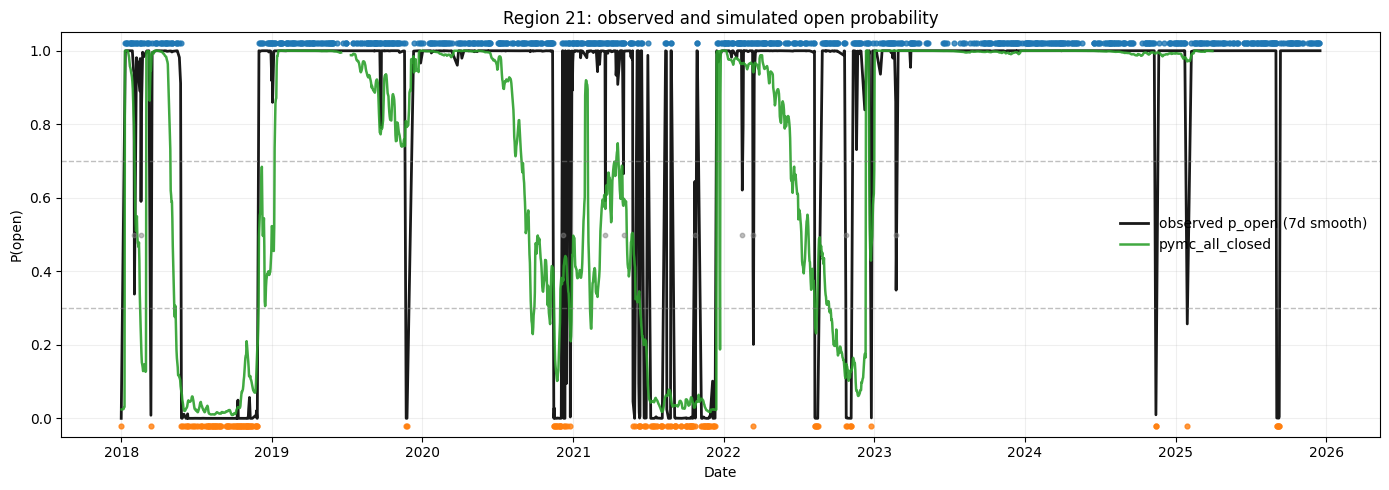

In [45]:
_ = plot_region_timeseries(
    sim_all=sim_all,
    model_df=timeline_df,
    region=21,
    models=[
        # "auto_regressive",
        # "gap_fill",
        # "single_step",
        # "all_open",
        # "all_closed",
        "pymc_all_closed",
        # "pymc_all_open",
    ],
    smooth_days=7,
    max_line_gap_days=7,
    # date_min="2024-01-01",
    # date_max="2019-10-01",
    # save_path="/Users/kyledorman/Desktop/48_open_closed.png"
)

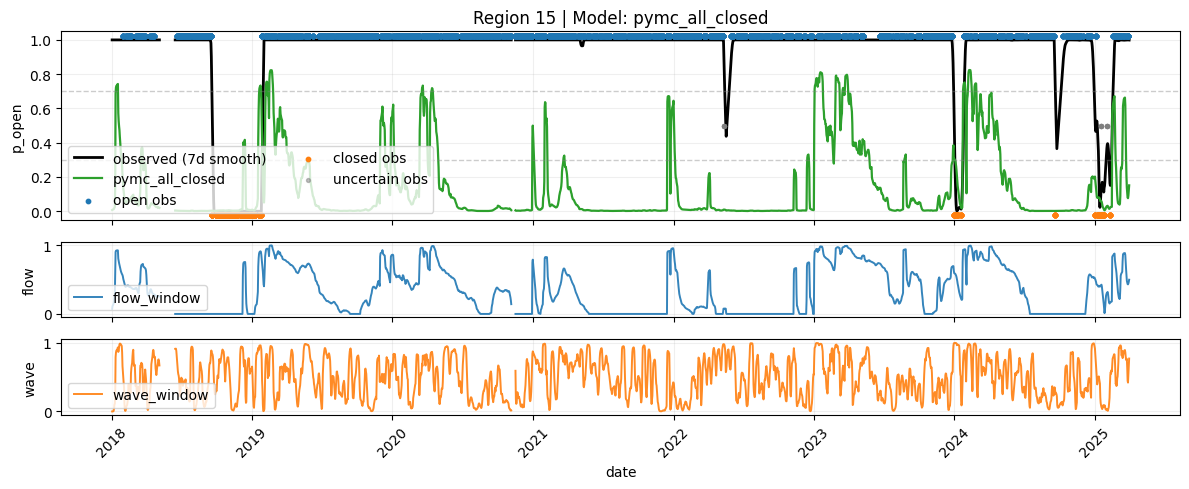

Santa Margarita Lagoon


In [76]:
region = 15

_ = plot_region_model_with_inputs(
    sim_all=sim_all,
    record_df=record_df,
    region=region,
    model_name="pymc_all_closed",
    # start="2023-09-01",
    # end="2023-12-21",
    smooth_days=7,
    model_colors=MODEL_COLORS,
    # save_path="/Users/kyledorman/Desktop/open_48_2018.png",
)
print(gdf.loc[region].Estuary_Name)

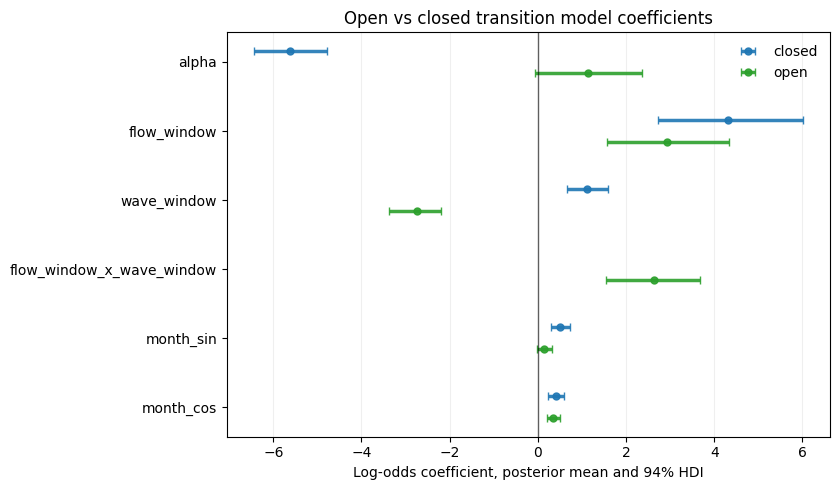

In [21]:
def coefficient_summary_for_plot(trace, var_names, model_label, hdi_prob=0.94):
    summ = az.summary(
        trace,
        var_names=var_names,
        hdi_prob=hdi_prob,
    ).copy()

    hdi_cols = [c for c in summ.columns if c.startswith("hdi_")]
    low_col, high_col = hdi_cols[0], hdi_cols[1]

    out = summ.reset_index(names="term").copy()

    out["term_clean"] = (
        out["term"]
        .str.replace("beta_fixed\\[", "", regex=True)
        .str.replace("\\]", "", regex=True)
        .str.replace("beta_", "", regex=False)
    )

    out["model"] = model_label
    out["hdi_low"] = out[low_col]
    out["hdi_high"] = out[high_col]
    out["significant"] = (out["hdi_low"] > 0) | (out["hdi_high"] < 0)

    return out[
        [
            "model",
            "term",
            "term_clean",
            "mean",
            "sd",
            "hdi_low",
            "hdi_high",
            "significant",
        ]
    ]


open_coef = coefficient_summary_for_plot(
    trace=open_traces["open_no_daily_hier_flow_window"],
    var_names=[
        "alpha",
        "beta_fixed",
        "beta_flow_window",
    ],
    model_label="open",
)

closed_coef = coefficient_summary_for_plot(
    trace=closed_traces["closed_no_daily_hier_flow_window_no_interaction"],
    var_names=[
        "alpha",
        "beta_fixed",
        "beta_flow_window",
    ],
    model_label="closed",
)

coef_both = pd.concat([open_coef, closed_coef], ignore_index=True)


def plot_open_closed_coefficients(
    coef_both,
    title="Open vs closed transition model coefficients",
    figsize=(8.5, 5),
):
    term_order = [
        "alpha",
        "flow_window",
        "wave_window",
        "flow_window_x_wave_window",
        "month_sin",
        "month_cos",
    ]

    terms = [term for term in term_order if term in coef_both["term_clean"].unique()]

    y_lookup = {term: i for i, term in enumerate(terms)}
    offsets = {
        "open": 0.16,
        "closed": -0.16,
    }
    colors = {
        "open": "tab:green",
        "closed": "tab:blue",
    }

    fig, ax = plt.subplots(figsize=figsize)

    for model_name, sub in coef_both.groupby("model"):
        sub = sub[sub["term_clean"].isin(terms)].copy()

        y = sub["term_clean"].map(y_lookup).to_numpy() + offsets[model_name]

        xerr = np.vstack(
            [
                sub["mean"].to_numpy() - sub["hdi_low"].to_numpy(),
                sub["hdi_high"].to_numpy() - sub["mean"].to_numpy(),
            ]
        )

        ax.errorbar(
            sub["mean"],
            y,
            xerr=xerr,
            fmt="o",
            color=colors[model_name],
            ecolor=colors[model_name],
            elinewidth=2.5,
            capsize=3,
            markersize=5,
            alpha=0.9,
            label=model_name,
        )

    ax.axvline(0, color="black", linewidth=1, alpha=0.6)

    ax.set_yticks(np.arange(len(terms)))
    ax.set_yticklabels(terms)
    ax.invert_yaxis()

    ax.set_xlabel("Log-odds coefficient, posterior mean and 94% HDI")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(axis="x", alpha=0.2)

    fig.tight_layout()

    return fig, ax


fig, ax = plot_open_closed_coefficients(coef_both)
fig.savefig("/Users/kyledorman/Desktop/model_coeffs.png")

In [22]:
def summarize_open_region_terms(
    trace_open,
    region_levels_open,
    train_df,
    hdi_prob=0.94,
):
    posterior = trace_open.posterior.stack(sample=("chain", "draw"))

    region_intercept = posterior["region_intercept"]
    region_flow_dev = posterior["region_flow_window_dev"]

    beta_flow = posterior["beta_flow_window"]
    flow_slope = beta_flow + region_flow_dev

    rows = []

    for region in region_levels_open:
        intercept_samples = region_intercept.sel(region=region).values
        slope_samples = flow_slope.sel(region=region).values

        rows.append(
            {
                "region": region,
                "region_intercept_mean": intercept_samples.mean(),
                "region_intercept_sd": intercept_samples.std(),
                "flow_window_slope_mean": slope_samples.mean(),
                "flow_window_slope_sd": slope_samples.std(),
                "intercept_hdi_low": az.hdi(intercept_samples, hdi_prob=hdi_prob)[0],
                "intercept_hdi_high": az.hdi(intercept_samples, hdi_prob=hdi_prob)[1],
                "slope_hdi_low": az.hdi(slope_samples, hdi_prob=hdi_prob)[0],
                "slope_hdi_high": az.hdi(slope_samples, hdi_prob=hdi_prob)[1],
            }
        )

    terms = pd.DataFrame(rows)

    empirical = (
        train_df[train_df["state_prev"] == "open"]
        .groupby("region")
        .agg(
            mean_persistence_rate=("is_open", "mean"),
            n_open_obs=("is_open", "size"),
        )
        .reset_index()
    )

    terms = terms.merge(empirical, on="region", how="left")

    return terms


def summarize_closed_region_terms(
    trace_closed,
    region_levels_closed,
    train_df,
    hdi_prob=0.94,
):
    posterior = trace_closed.posterior.stack(sample=("chain", "draw"))

    region_intercept = posterior["region_intercept"]
    region_flow_dev = posterior["region_flow_window_dev"]

    beta_flow = posterior["beta_flow_window"]
    flow_slope = beta_flow + region_flow_dev

    rows = []

    for i, region in enumerate(region_levels_closed):
        intercept_samples = region_intercept.sel(region=region).values
        slope_samples = flow_slope.sel(region=region).values

        rows.append(
            {
                "region": region,
                "region_intercept_mean": intercept_samples.mean(),
                "region_intercept_sd": intercept_samples.std(),
                "flow_window_slope_mean": slope_samples.mean(),
                "flow_window_slope_sd": slope_samples.std(),
                "intercept_hdi_low": az.hdi(intercept_samples, hdi_prob=hdi_prob)[0],
                "intercept_hdi_high": az.hdi(intercept_samples, hdi_prob=hdi_prob)[1],
                "slope_hdi_low": az.hdi(slope_samples, hdi_prob=hdi_prob)[0],
                "slope_hdi_high": az.hdi(slope_samples, hdi_prob=hdi_prob)[1],
            }
        )

    terms = pd.DataFrame(rows)

    empirical = (
        train_df[train_df["state_prev"] == "closed"]
        .groupby("region")
        .agg(
            mean_reopen_rate=("is_open", "mean"),
            n_closed_obs=("is_open", "size"),
        )
        .reset_index()
    )

    terms = terms.merge(empirical, on="region", how="left")

    return terms


open_region_terms = summarize_open_region_terms(
    trace_open=open_traces["open_no_daily_hier_flow_window"],
    region_levels_open=open_region_levels["open_no_daily_hier_flow_window"],
    train_df=train_df,
)

closed_region_terms = summarize_closed_region_terms(
    trace_closed=closed_traces["closed_no_daily_hier_flow_window_no_interaction"],
    region_levels_closed=closed_region_levels["closed_no_daily_hier_flow_window_no_interaction"],
    train_df=train_df,
)

In [23]:
[c for c in record_df.columns if "flow" in c]

['streamflow_mean',
 'streamflow_median',
 'streamflow_p90',
 'streamflow_max',
 'flow_n_obs',
 'streamflow_mean_rank_norm',
 'streamflow_median_rank_norm',
 'streamflow_p90_rank_norm',
 'streamflow_max_rank_norm',
 'flow_sum_rolling_3d',
 'flow_sum_rolling_5d',
 'flow_sum_rolling_7d',
 'flow_daily',
 'flow_window',
 'flow_daily_lag1',
 'flow_window_lag1',
 'flow_window_x_wave_window',
 'flow_window_x_wave_daily',
 'flow_daily_x_wave_window',
 'flow_daily_x_wave_daily',
 'daily_flow_wave_tide']

In [24]:
open_raw_flow_by_region = (
    record_df[record_df["prev_state"] == "open"]
    .groupby("region")
    .agg(
        mean_ranked_flow_prev_open=("flow_window_lag1", "mean"),
        # median_raw_flow_prev_open=("flow_window", "median"),
        # sd_raw_flow_prev_open=("flow_window", "std"),
    )
    .reset_index()
)

open_region_terms = open_region_terms.merge(
    open_raw_flow_by_region,
    on="region",
    how="left",
)
closed_raw_flow_by_region = (
    record_df[record_df["prev_state"] == "closed"]
    .groupby("region")
    .agg(
        mean_ranked_flow_prev_closed=("flow_window_lag1", "mean"),
        # median_raw_flow_prev_open=("flow_window", "median"),
        # sd_raw_flow_prev_open=("flow_window", "std"),
    )
    .reset_index()
)

closed_region_terms = closed_region_terms.merge(
    closed_raw_flow_by_region,
    on="region",
    how="left",
)

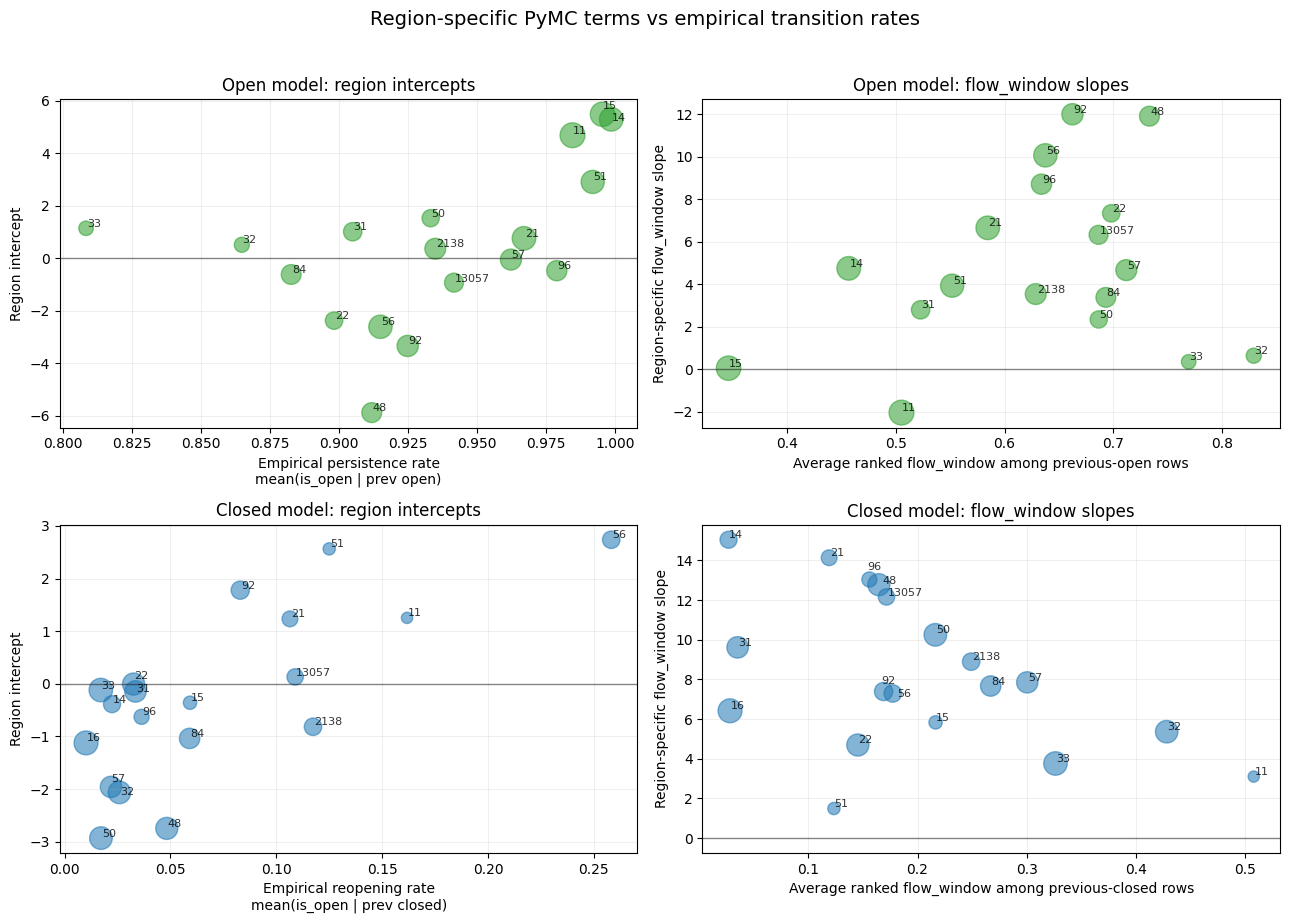

In [25]:
from adjustText import adjust_text


def label_points_adjusted(ax, df, x_col, y_col, label_col="region", fontsize=8):
    texts = []

    for _, row in df.iterrows():
        if pd.isna(row[x_col]) or pd.isna(row[y_col]):
            continue

        texts.append(
            ax.text(
                row[x_col],
                row[y_col],
                str(row[label_col].astype(int)),
                fontsize=fontsize,
                alpha=0.8,
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", alpha=0.35, lw=0.7),
    )


def plot_region_terms_2x2(
    open_region_terms,
    closed_region_terms,
    label_regions=True,
    figsize=(13, 9),
):
    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        sharex=False,
        sharey=False,
    )

    panels = [
        {
            "ax": axes[0, 0],
            "df": open_region_terms,
            "x": "mean_persistence_rate",
            "y": "region_intercept_mean",
            "n": "n_open_obs",
            "color": "tab:green",
            "title": "Open model: region intercepts",
            "xlabel": "Empirical persistence rate\nmean(is_open | prev open)",
            "ylabel": "Region intercept",
        },
        {
            "ax": axes[0, 1],
            "df": open_region_terms,
            "x": "mean_ranked_flow_prev_open",
            "y": "flow_window_slope_mean",
            "n": "n_open_obs",
            "color": "tab:green",
            "title": "Open model: flow_window slopes",
            "xlabel": "Average ranked flow_window among previous-open rows",
            "ylabel": "Region-specific flow_window slope",
        },
        {
            "ax": axes[1, 0],
            "df": closed_region_terms,
            "x": "mean_reopen_rate",
            "y": "region_intercept_mean",
            "n": "n_closed_obs",
            "color": "tab:blue",
            "title": "Closed model: region intercepts",
            "xlabel": "Empirical reopening rate\nmean(is_open | prev closed)",
            "ylabel": "Region intercept",
        },
        {
            "ax": axes[1, 1],
            "df": closed_region_terms,
            "x": "mean_ranked_flow_prev_closed",
            "y": "flow_window_slope_mean",
            "n": "n_closed_obs",
            "color": "tab:blue",
            "title": "Closed model: flow_window slopes",
            "xlabel": "Average ranked flow_window among previous-closed rows",
            "ylabel": "Region-specific flow_window slope",
        },
    ]

    for panel in panels:
        ax = panel["ax"]
        d = panel["df"].copy()

        size = np.sqrt(d[panel["n"]].fillna(0)) * 8

        ax.scatter(
            d[panel["x"]],
            d[panel["y"]],
            s=size,
            alpha=0.55,
            color=panel["color"],
        )

        if label_regions:
            label_points(
                ax,
                d,
                x_col=panel["x"],
                y_col=panel["y"],
                label_col="region",
                fontsize=7,
            )

        ax.axhline(0, color="black", linewidth=1, alpha=0.45)
        ax.set_title(panel["title"])
        ax.set_xlabel(panel["xlabel"])
        ax.set_ylabel(panel["ylabel"])
        ax.grid(True, alpha=0.2)

    fig.suptitle(
        "Region-specific PyMC terms vs empirical transition rates",
        y=1.02,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, axes


def plot_region_terms_2x2_adjusted(
    open_region_terms,
    closed_region_terms,
    figsize=(13, 9),
):
    fig, axes = plot_region_terms_2x2(
        open_region_terms=open_region_terms,
        closed_region_terms=closed_region_terms,
        label_regions=False,
        figsize=figsize,
    )

    label_points_adjusted(
        axes[0, 0],
        open_region_terms,
        "mean_persistence_rate",
        "region_intercept_mean",
    )
    label_points_adjusted(
        axes[0, 1],
        open_region_terms,
        "mean_ranked_flow_prev_open",
        "flow_window_slope_mean",
    )
    label_points_adjusted(
        axes[1, 0],
        closed_region_terms,
        "mean_reopen_rate",
        "region_intercept_mean",
    )
    label_points_adjusted(
        axes[1, 1],
        closed_region_terms,
        "mean_ranked_flow_prev_closed",
        "flow_window_slope_mean",
    )

    fig.tight_layout()

    return fig, axes


fig, axes = plot_region_terms_2x2_adjusted(
    open_region_terms=open_region_terms[open_region_terms.region != 16],
    closed_region_terms=closed_region_terms,
    # label_regions=True,
)
fig.savefig("/Users/kyledorman/Desktop/region_coeffs.png")

In [ ]:
eval_df = sim_all[sim_all.model == "pymc_all_closed"].copy().reset_index(drop=True)

cols = []
for window_days in [3, 5, 7, 14]:
    window = f"{window_days}D"
    result = pd.Series(np.nan, index=eval_df.index, dtype=float)

    for _, group in eval_df.sort_values(["region", "date"]).groupby("region", sort=False):
        rolled = (
            group.set_index("date")["p_open_sim"]
            .rolling(window=window, min_periods=1, center=True)
            .agg("max")
        )
        result.loc[group.index] = rolled.to_numpy()

    col = f"p_open_sim_window_{window_days}D"
    cols.append(col)
    eval_df[col] = result

score_df = pd.merge(
    eval_df[["region", "date", "p_open", "p_open_sim", *cols]],
    train_df[["region", "label_date", "label_window_type", "state", "transition"]].rename(
        columns={"label_date": "date"}
    ),
    left_on=["region", "date"],
    right_on=["region", "date"],
).sort_values(by=["region", "date"])
score_df.head(2)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)


def make_opening_score_df(
    score_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Keep rows relevant to opening detection.

    Positive rows are closed_to_open.
    Negative rows are closed_to_closed.
    """
    opening_mask = score_df["transition"] == "opening"
    closed_mask = (score_df["transition"] == "persistence") & (score_df["state"] == "closed")
    out = score_df.loc[opening_mask | closed_mask].copy()

    out["y_opening"] = opening_mask.astype(int)

    return out


def opening_row_metrics(
    opening_df: pd.DataFrame,
    score_cols: list[str],
) -> pd.DataFrame:
    rows = []

    for score_col in score_cols:
        df = opening_df.loc[opening_df[score_col].notna()].copy()

        y = df["y_opening"].to_numpy()
        score = df[score_col].to_numpy()

        row = {
            "score_col": score_col,
            "n_rows": len(df),
            "n_positive": int(y.sum()),
            "n_negative": int((1 - y).sum()),
            "positive_rate": float(y.mean()),
            "auprc": average_precision_score(y, score),
            "brier": brier_score_loss(y, score),
            "log_loss": log_loss(y, np.clip(score, 1e-6, 1 - 1e-6)),
        }

        if len(np.unique(y)) == 2:
            row["auroc"] = roc_auc_score(y, score)
        else:
            row["auroc"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values("auprc", ascending=False)


def opening_threshold_table(
    opening_df: pd.DataFrame,
    score_col: str,
    thresholds=(0.1, 0.2, 0.3, 0.5, 0.7, 0.9),
) -> pd.DataFrame:
    df = opening_df.loc[opening_df[score_col].notna()].copy()

    y = df["y_opening"].to_numpy()
    score = df[score_col].to_numpy()

    rows = []
    for threshold in thresholds:
        y_pred = score >= threshold

        rows.append(
            {
                "score_col": score_col,
                "threshold": threshold,
                "n_alerts": int(y_pred.sum()),
                "alert_rate": float(y_pred.mean()),
                "precision": precision_score(y, y_pred, zero_division=0),
                "recall": recall_score(y, y_pred, zero_division=0),
                "f1": f1_score(y, y_pred, zero_division=0),
            }
        )

    return pd.DataFrame(rows)


def opening_calibration_table(
    opening_df: pd.DataFrame,
    score_col: str,
    n_bins: int = 10,
) -> pd.DataFrame:
    df = opening_df.loc[opening_df[score_col].notna()].copy()

    df["score_bin"] = pd.qcut(
        df[score_col],
        q=n_bins,
        duplicates="drop",
    )

    return (
        df.groupby("score_bin", observed=True)
        .agg(
            n=("y_opening", "size"),
            mean_score=(score_col, "mean"),
            observed_rate=("y_opening", "mean"),
            n_positive=("y_opening", "sum"),
        )
        .reset_index()
    )

In [ ]:
score_cols = [
    "p_open_sim",
    "p_open_sim_window_3D",
    "p_open_sim_window_5D",
    "p_open_sim_window_7D",
    "p_open_sim_window_14D",
]

opening_df = make_opening_score_df(score_df)

metrics_df = opening_row_metrics(opening_df, score_cols)

metrics_df.round(3)

In [ ]:
thresholds_df = pd.concat(
    [opening_threshold_table(opening_df, score_col) for score_col in score_cols],
    ignore_index=True,
)

thresholds_df.sort_values("f1", ascending=False).reset_index(drop=True)

In [ ]:
best_score_col = metrics_df.iloc[0]["score_col"]

cal_df = opening_calibration_table(
    opening_df,
    score_col=best_score_col,
    n_bins=10,
)

cal_df

In [ ]:
import numpy as np
import pandas as pd


def make_state_row_eval_df(
    score_df: pd.DataFrame,
    pred_col: str = "p_open_sim",
    state_col: str = "state",
) -> pd.DataFrame:
    eval_df = score_df.copy()

    eval_df["y_open"] = eval_df[state_col].eq("open").astype(int)
    eval_df["score"] = eval_df[pred_col]

    return eval_df.loc[eval_df["score"].notna() & eval_df["y_open"].notna()].copy()


def state_row_metrics(eval_df: pd.DataFrame) -> dict:
    y = eval_df["y_open"].to_numpy()
    score = eval_df["score"].to_numpy()

    metrics = {
        "n_rows": len(eval_df),
        "n_open": int(y.sum()),
        "n_closed": int((1 - y).sum()),
        "open_rate": float(y.mean()),
        "auprc": average_precision_score(y, score),
        "brier": brier_score_loss(y, score),
        "log_loss": log_loss(y, np.clip(score, 1e-6, 1 - 1e-6)),
    }

    if len(np.unique(y)) == 2:
        metrics["auroc"] = roc_auc_score(y, score)
    else:
        metrics["auroc"] = np.nan

    return metrics


def state_threshold_table(
    eval_df: pd.DataFrame,
    thresholds=(0.1, 0.2, 0.3, 0.5, 0.7, 0.9),
) -> pd.DataFrame:
    y = eval_df["y_open"].to_numpy()
    score = eval_df["score"].to_numpy()

    rows = []
    for threshold in thresholds:
        y_pred = score >= threshold

        rows.append(
            {
                "threshold": threshold,
                "n_pred_open": int(y_pred.sum()),
                "pred_open_rate": float(y_pred.mean()),
                "precision": precision_score(y, y_pred, zero_division=0),
                "recall": recall_score(y, y_pred, zero_division=0),
                "f1": f1_score(y, y_pred, zero_division=0),
            }
        )

    return pd.DataFrame(rows)


def state_calibration_table(
    eval_df: pd.DataFrame,
    n_bins: int = 10,
) -> pd.DataFrame:
    df = eval_df.copy()

    df["score_bin"] = pd.qcut(
        df["score"],
        q=n_bins,
        duplicates="drop",
    )

    return (
        df.groupby("score_bin", observed=True)
        .agg(
            n=("y_open", "size"),
            mean_pred_open=("score", "mean"),
            observed_open_rate=("y_open", "mean"),
            n_open=("y_open", "sum"),
        )
        .reset_index()
    )

In [ ]:
state_eval_df = make_state_row_eval_df(
    opening_df,
    pred_col="p_open_sim",
    state_col="state",
)

state_metrics = state_row_metrics(state_eval_df)
state_metrics

In [ ]:
def state_metrics_by_region(eval_df):
    rows = []

    for region, g in eval_df.groupby("region"):
        if g["y_open"].nunique() < 2:
            continue

        y = g["y_open"].to_numpy()
        s = g["score"].to_numpy()

        rows.append(
            {
                "region": region,
                "n": len(g),
                "open_rate": y.mean(),
                "auprc": average_precision_score(y, s),
                "auroc": roc_auc_score(y, s),
                "brier": brier_score_loss(y, s),
                "mean_score_open": s[y == 1].mean(),
                "mean_score_closed": s[y == 0].mean(),
            }
        )

    return pd.DataFrame(rows).sort_values("auprc")


region_metrics = state_metrics_by_region(state_eval_df)
region_metrics

In [ ]:
import numpy as np
import pandas as pd


def make_label_centric_scores(
    score_df: pd.DataFrame,
    pred_cols: list[str],
    window_days_list=(0, 3, 5, 7, 14),
    label_date_col: str = "date",
    label_cols=("region", "date", "state", "transition"),
) -> pd.DataFrame:
    """
    For each labeled row, compute max prediction value within +/- N days
    around that label date, within region.

    Returns one row per original label row, with added max-window score columns.
    """
    labels = score_df.loc[:, list(label_cols)].copy()
    labels = labels.reset_index(drop=True)
    labels["label_id"] = labels.index
    labels[label_date_col] = pd.to_datetime(labels[label_date_col])

    pred = score_df.loc[:, ["region", "date", *pred_cols]].copy()
    pred["date"] = pd.to_datetime(pred["date"])

    out = labels.copy()

    joined = labels[["label_id", "region", label_date_col]].merge(
        pred,
        on="region",
        how="left",
        suffixes=("_label", "_pred"),
    )

    label_date_name = label_date_col
    pred_date_name = "date"

    # If label_date_col is also "date", merge creates date_x/date_y.
    if label_date_col == "date":
        label_date_name = "date_label"
        pred_date_name = "date_pred"

    for window_days in window_days_list:
        delta = pd.to_timedelta(window_days, unit="D")

        in_window = joined.loc[
            joined[pred_date_name].between(
                joined[label_date_name] - delta,
                joined[label_date_name] + delta,
            )
        ].copy()

        agg = (
            in_window.groupby("label_id")[pred_cols]
            .max()
            .rename(columns={col: f"{col}_label_window_max_{window_days}D" for col in pred_cols})
            .reset_index()
        )

        out = out.merge(agg, on="label_id", how="left")

    return out

In [ ]:
pred_cols = [
    "p_open_sim",
    # include others if present/useful:
    # "p_open_sim_window_3D",
    # "p_open_sim_window_5D",
    # "p_open_sim_window_7D",
    # "p_open_sim_window_14D",
]

label_window_df = make_label_centric_scores(
    score_df=score_df,
    pred_cols=pred_cols,
    window_days_list=[0, 3, 5, 7, 14],
)

label_window_df.head()

In [ ]:
def evaluate_label_centric_opening(
    opening_label_df: pd.DataFrame,
    score_cols: list[str],
) -> pd.DataFrame:
    rows = []

    for score_col in score_cols:
        df = opening_label_df.loc[opening_label_df[score_col].notna()].copy()

        y = df["y_opening"].to_numpy()
        score = df[score_col].to_numpy()

        row = {
            "score_col": score_col,
            "n_labels": len(df),
            "n_positive": int(y.sum()),
            "n_negative": int((1 - y).sum()),
            "positive_rate": float(y.mean()),
            "auprc": average_precision_score(y, score),
        }

        if len(np.unique(y)) == 2:
            row["auroc"] = roc_auc_score(y, score)
        else:
            row["auroc"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values("auprc", ascending=False)


opening_label_df = make_opening_score_df(label_window_df)

opening_label_df.head()

In [ ]:
label_score_cols = [
    "p_open_sim_label_window_max_0D",
    "p_open_sim_label_window_max_3D",
    "p_open_sim_label_window_max_5D",
    "p_open_sim_label_window_max_7D",
    "p_open_sim_label_window_max_14D",
]

label_metrics_df = evaluate_label_centric_opening(
    opening_label_df,
    score_cols=label_score_cols,
)

label_metrics_df

In [ ]:
def label_threshold_table(
    opening_label_df: pd.DataFrame,
    score_col: str,
    thresholds=(0.1, 0.2, 0.3, 0.5, 0.7, 0.9),
) -> pd.DataFrame:
    df = opening_label_df.loc[opening_label_df[score_col].notna()].copy()

    y = df["y_opening"].to_numpy()
    score = df[score_col].to_numpy()

    rows = []
    for threshold in thresholds:
        y_pred = score >= threshold

        rows.append(
            {
                "score_col": score_col,
                "threshold": threshold,
                "n_alerts": int(y_pred.sum()),
                "precision": precision_score(y, y_pred, zero_division=0),
                "recall": recall_score(y, y_pred, zero_division=0),
                "f1": f1_score(y, y_pred, zero_division=0),
            }
        )

    return pd.DataFrame(rows)


thresholds_df = pd.concat(
    [label_threshold_table(opening_label_df, score_col) for score_col in label_score_cols],
    ignore_index=True,
)

thresholds_df.sort_values("f1", ascending=False)

In [ ]:
def label_threshold_table_by_region(
    opening_label_df: pd.DataFrame,
    score_col: str,
    thresholds=(0.1, 0.2, 0.3, 0.5, 0.7, 0.9),
    region_col: str = "region",
) -> pd.DataFrame:
    rows = []

    for region, group in opening_label_df.groupby(region_col, observed=True):
        df = group.loc[group[score_col].notna()].copy()

        if df.empty:
            continue

        y = df["y_opening"].to_numpy()
        score = df[score_col].to_numpy()

        for threshold in thresholds:
            y_pred = score >= threshold

            rows.append(
                {
                    region_col: region,
                    "score_col": score_col,
                    "threshold": threshold,
                    "n_labels": len(df),
                    "n_positive": int(y.sum()),
                    "n_negative": int((1 - y).sum()),
                    "n_alerts": int(y_pred.sum()),
                    "alert_rate": float(y_pred.mean()),
                    "precision": precision_score(y, y_pred, zero_division=0),
                    "recall": recall_score(y, y_pred, zero_division=0),
                    "f1": f1_score(y, y_pred, zero_division=0),
                }
            )

    return pd.DataFrame(rows)


def average_label_threshold_table_over_regions(
    opening_label_df: pd.DataFrame,
    score_col: str,
    thresholds=(0.1, 0.2, 0.3, 0.5, 0.7, 0.9),
    region_col: str = "region",
) -> pd.DataFrame:
    region_stats = label_threshold_table_by_region(
        opening_label_df=opening_label_df,
        score_col=score_col,
        thresholds=thresholds,
        region_col=region_col,
    )

    avg = (
        region_stats.groupby(["score_col", "threshold"], observed=True)
        .agg(
            n_regions=(region_col, "nunique"),
            mean_n_labels=("n_labels", "mean"),
            mean_n_positive=("n_positive", "mean"),
            mean_n_alerts=("n_alerts", "mean"),
            mean_alert_rate=("alert_rate", "mean"),
            mean_precision=("precision", "mean"),
            mean_recall=("recall", "mean"),
            mean_f1=("f1", "mean"),
            sd_precision=("precision", "std"),
            sd_recall=("recall", "std"),
            sd_f1=("f1", "std"),
        )
        .reset_index()
    )

    return avg

In [ ]:
region_avg_thresholds_df = pd.concat(
    [
        average_label_threshold_table_over_regions(
            opening_label_df,
            score_col=score_col,
        )
        for score_col in label_score_cols
    ],
    ignore_index=True,
)

region_avg_thresholds_df.sort_values("mean_f1", ascending=False)

In [ ]:
region_thresholds_df = pd.concat(
    [
        label_threshold_table_by_region(
            opening_label_df,
            score_col=score_col,
        )
        for score_col in label_score_cols
    ],
    ignore_index=True,
)

region_thresholds_df.head()